### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
df = pd.read_csv("grades_crpt.csv")

# **Explore the Database**

In [88]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


I notice that there are already some null (NaN) values within the database

I also notice that there are some students that have either gotten 0 or no grades on all of their assignments.

I also notice that the final must have been significantly harder than the assignments because students that did well during assignments seemed to perform worse during the final.

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB


This confirms that not all columns are entirely filled. These rows will either need to be deleted, or I need to find a way to substitute in values because otherwise this will mess with the statistics.

In [90]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


There must be an error in the entry of some grades because the lowest grade (min) is negative in A1, A2, A3, A4, and A6. This is not possible, as the lowest grade students can get is 0. This implies something is wrong.

I also notice that the max for all grades is above 100. This is not possible given that most grades are given on a [0, 100] interval, and not more or less.

I also notice that the strongest assignment is A5 with a mean of 89.64 but I am also curious about whether this is simply due to the errors in the entries of A1-A6, excluding A5. In contrast, the weakest column/grades are in the final_exam column. This could also simply be due to errors in the grades of A1-A4 and A6.

The standard deviation also seems quite high for all assignments except for final_exam indicating a wide spread of grades.

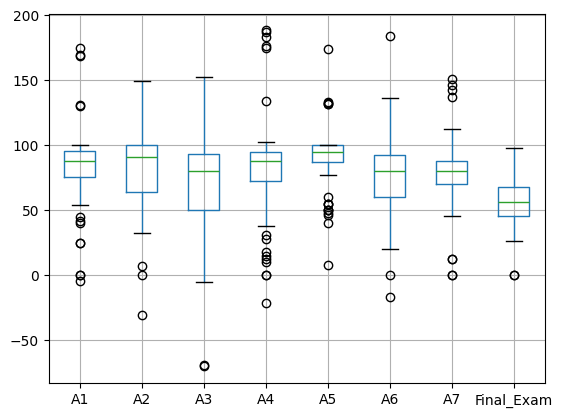

In [91]:
df.boxplot(column=["A1", "A2", "A3", "A4", "A5", "A6", "A7","Final_Exam"])
plt.show()

This boxplot shows that there are also various outliers for every single exam. The only column that looks normal is the Final_Exam because the outlier is 0.

For A1, A2,A3, A4, and A6 there are outliers that are below 0 which is an error.

Then in A1, A4, A5, A6, and A7 there are outliers that are above 100 which are also errors.

The min and max for all assignments and final exam should be 0 and 100.

# **Check the Correlation**

In [92]:
numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
corr_matrix = df[numeric_cols].corr()

print(corr_matrix.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.14  0.36  0.30  0.24  0.23 -0.02        0.21
A2         -0.14  1.00  0.21 -0.03  0.01  0.36  0.03        0.28
A3          0.36  0.21  1.00  0.19  0.19 -0.03  0.15        0.28
A4          0.30 -0.03  0.19  1.00  0.04  0.15  0.22        0.40
A5          0.24  0.01  0.19  0.04  1.00  0.24  0.03        0.02
A6          0.23  0.36 -0.03  0.15  0.24  1.00  0.15        0.25
A7         -0.02  0.03  0.15  0.22  0.03  0.15  1.00        0.38
Final_Exam  0.21  0.28  0.28  0.40  0.02  0.25  0.38        1.00


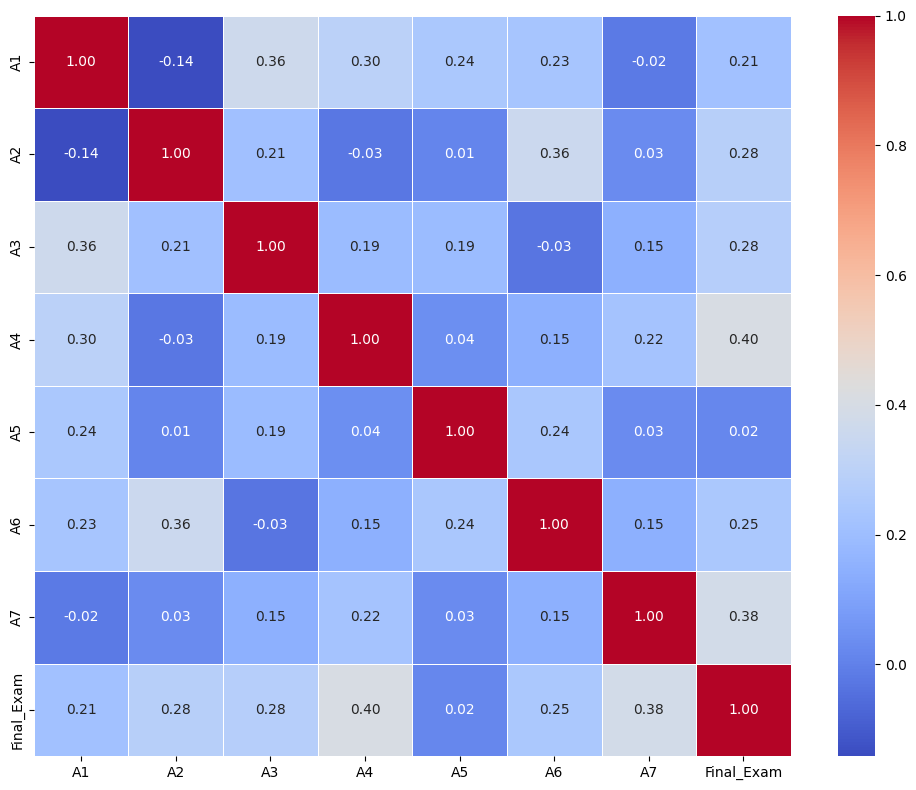

In [93]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.tight_layout()
plt.show()

From the correlation matrix, we can infer that A4 has the best correlation to Final_Exam performance. With a 0.40 correlation this isn't the strongest indicator, however, compared to all of the other assignments, students that did well on A4 are more likely to do better on the final exam. A7 is also a fairly good indicator of the final_exam performance as it has the second strongest correlation with it at 0.38.

In contrast, A5 seems to have the weakest correlation with the final exam with 0.02.

The only other correlation that stood out in terms of strength is A2 and A6 with a correlation of 0.36. Although it is not immensely strong, it is the second strongest one on the matrix.

Other correlations that stood out is the negative correlation between A1 and A2, A2 and A4, A3 and A6, and A1 and A7. Although not strong negative correlations they do hint at that when students perform better on one, they perform worse on the second one.

# If you could only use two assignment grades to predict the final exam, which ones would you choose — and why?

If I could use only 2 assignments to predict the final exam, I would use A4 and A7.

I chose A4 because it has the strongest correlation with the final_exam at 0.40.

And I chose A7 because it has the second strongest correlation with the final_exam at 0.38.

Although both of these aren't shockingly high they fare well in comparison to the other correlation values, and indicate that the better the user/student performs at these assignments, the more likely they are to perform better at the final exam.

# **Check for Missing Values**

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB


From df.info() we can see that there are a total of 86 records/entries. The only 2 entries with all 86 entries present are the user_id which is used to simply identify the user and final_exam.

All other entries are missing values.

* A1 is missing 86-57 = 29 values
* A2 is missing 86-61 = 25 values
* A3 is missing 86-62 = 24 values
* A4 is missing 86-77 = 9 values
* A5 is missing 86-61 = 25 values
* A6 is missing 86-67 = 19 values
* A7 is missing 86-76 = 10 values

# **Handle the Missing Values**

I am going to be handling the missing values in A4 and A7 because these two have the strongest correlation with the final exam. Therefore, in terms of predicting the final exam, having clean columns for both of these assignments would have the greatest impact.

I am going to judge the effectiveness of the method based on the correlation matrix. I want to find the method that best preserves the current correlation because my intention is not to alter the data, it is to simply clean it up and try to preserve as much data as I can, so ideally I find the best compromise between correlation and number of records preserved.

First I am going to copy user_id, A4, A7, and Final_Exam into a new dataframe, so that I can expirement.

In [95]:
new_df = df[['user_id', 'A4', 'A7', 'Final_Exam']].copy()

new_df

,user_id,A4,A7,Final_Exam
0,U001,75.0,50.6,68.8
1,U002,92.5,84.4,50.3
2,U003,86.2,NaN,67.8
3,U004,0.0,0.0,0.0
4,U005,0.0,NaN,0.0
...,...,...,...,...
81,U082,56.2,60.0,57.5
82,U083,174.8,146.4,64.1
83,U084,27.5,75.0,45.6
84,U085,100.0,0.0,30.6


### Drop Missing Values

Remove rows with NaN.

In [96]:
drop_df = new_df.copy()

drop_df = drop_df.dropna()

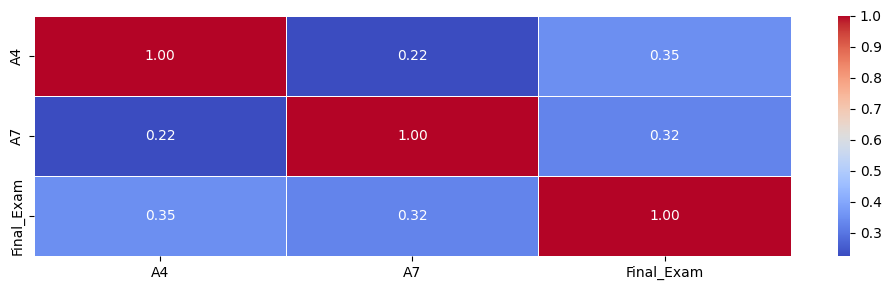

In [97]:
numeric_cols = ['A4', 'A7', 'Final_Exam']
corr_matrix = drop_df[numeric_cols].corr()

plt.figure(figsize=(10, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.tight_layout()
plt.show()

### Fill Using Mean

Fill using average.

In [98]:
mean_df = new_df.copy()

mean_df = mean_df.fillna(mean_df.mean(numeric_only=True))

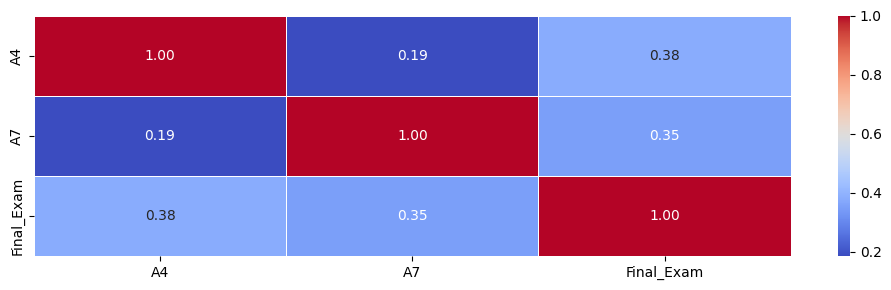

In [99]:
numeric_cols = ['A4', 'A7', 'Final_Exam']
corr_matrix = mean_df[numeric_cols].corr()

plt.figure(figsize=(10, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.tight_layout()
plt.show()

### Fill Using Median

Fill using middle value.

In [100]:
median_df = new_df.copy()

median_df = median_df.fillna(median_df.median(numeric_only=True))

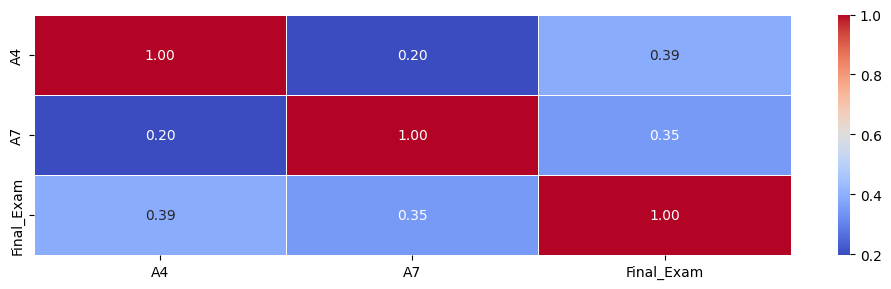

In [101]:
numeric_cols = ['A4', 'A7', 'Final_Exam']
corr_matrix = median_df[numeric_cols].corr()

plt.figure(figsize=(10, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.tight_layout()
plt.show()

### Fill Using Zero

I wanted to try this method because it makes sense that if you are missing an assignment that you get 0 on it. However, I do expect this to alter the correlation heavily.

In [102]:
zero_df = new_df.copy()

zero_df = zero_df.fillna(0)

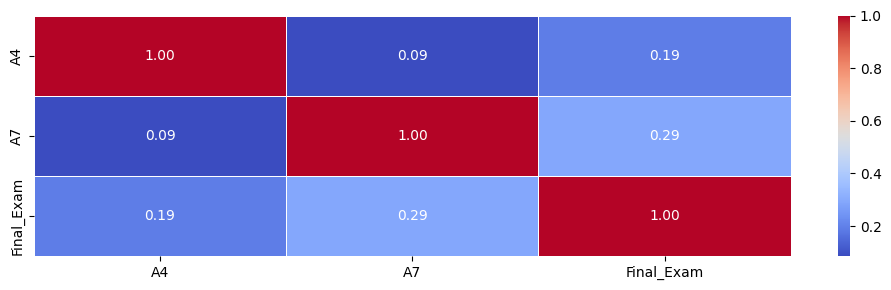

In [103]:
numeric_cols = ['A4', 'A7', 'Final_Exam']
corr_matrix = zero_df[numeric_cols].corr()

plt.figure(figsize=(10, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.tight_layout()
plt.show()

### Conclusion

My conclusion is that fill using median is the best method for handling missing values in this situation. This method has preserved the original amount of records which is 86 while staying the closest to the original correlation matrix.

* The correlation of A4 and Final_Exam has changed from 0.40 to 0.39 which is a difference of 0.01.

* The correlation of A7 and Final_Exam has changed from 0.38 to 0.35 which is a difference of 0.03.

* The correlation of A4 and A7 has changed from 0.22 to 0.20 which is a difference of 0.02.

These are changes but they aren't significant enough to highly alter the way the relationships between these assignments and exam are viewed. Additionally, the median method also preserved the original amount of 86 records. In my opinion, this is a good compromise given that the difference in correlation has been at max -0.03.

The other methods either lost numerous records, or had much higher changes in correlation which meant lack of integrity to the original correlations and dataframe.

# **Check for Outliers**

I am going to be checking outliers in A4 and A7 because these two have the strongest correlation with the final exam. Therefore, having clean columns for both of these assignments would have the greatest impact if our goal was to see the impact that assignments have on the final exam.

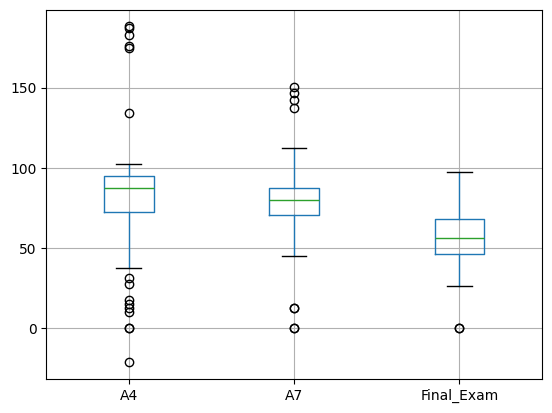

In [104]:
df.boxplot(column=["A4", "A7","Final_Exam"])
plt.show()

This boxplot shows that there are also various outliers for every single exam. The only column that looks normal is the Final_Exam because everything is between 0 and 100.

For A4 there are outliers that are below 0 which need cleaning.

Then in A4 and A7 there are outliers that are above 100 which also need cleaning.

The min and max for all assignments and final exam should be 0 and 100 according to my experience in school and standard grading systems.

**Therefore all of the values above 100 and below 0 seem unrealistic or suspicious.**

I decided to go with 0<=x<=100 method because the standard deviation method shown in lab could still count in values that go above or below 0 which would be counterintuitive to the argument I made above.

Additionally, I also believe that there are anomalies to the average score. It is very likely that a student just grasps a concept better than the class, or vice versa where they just can't seem to understand it. Therefore, all values between 0 and 100 don't bother me regardless of whether they lie within standard deviation.

In [105]:
def detect_outliers(df, column):
  lower_bound = 0
  higher_bound = 100

  return df[(df[column] < lower_bound) | (df[column] > higher_bound)]

a4_outliers = detect_outliers(df, "A4")

a7_outliers = detect_outliers(df, "A7")

final_exam_outliers = detect_outliers(df, "Final_Exam")


### A4 Outliers

In [106]:
print(a4_outliers)

       A1     A2    A3     A4     A5     A6     A7  Final_Exam user_id
6    95.8   64.3  63.0  175.8   85.0   76.0   83.8        64.4    U007
17    NaN   91.1   NaN  101.2   98.0  100.0   85.6        68.8    U018
24  130.7    NaN  85.0  188.2  100.0   80.0   85.0        68.8    U025
28    NaN   60.7   NaN  133.8  100.0   90.0   87.5        50.0    U029
30   83.3  100.0  60.0  183.1   90.0   70.0   78.8        49.1    U031
36   87.5    NaN   NaN  187.1    NaN    NaN    NaN        68.4    U037
57    NaN    NaN   NaN  102.5   87.0   80.0   83.8        66.6    U058
67   90.0  100.0  83.0  -21.6   97.0  100.0   81.2        67.5    U068
82   87.5  -30.6  70.0  174.8   91.0    NaN  146.4        64.1    U083


There are 9 outliers for A4 where 1 of them is below 0 and 8 are above 100. Looking at the box plot this makes sense given that A4 seemed to have the most amount of outliers out of the 3 columns and a lot of its outlier weight was greater than 150.

### A7 Outliers

In [107]:
print(a7_outliers)

       A1     A2     A3     A4     A5    A6     A7  Final_Exam user_id
5   100.0   92.9  100.0   96.2    NaN  80.0  110.5        97.5    U006
14   79.2  100.0  100.0   86.2    NaN  60.0  142.1        80.0    U015
50    NaN  107.1   90.0    NaN  100.0   NaN  136.9        89.7    U051
58   39.9    NaN    NaN   68.2   77.0  47.0  110.3        55.3    U059
68    NaN    NaN   80.0    NaN   87.0   NaN  150.6        69.1    U069
72   75.0  100.0   90.0   31.0   55.0  29.6  112.3        38.1    U073
82   87.5  -30.6   70.0  174.8   91.0   NaN  146.4        64.1    U083


There are 7 outliers for A7 and all of them are above 100 which makes sense when looking at the box plot.

### Final Exam Outliers

In [108]:
print(final_exam_outliers)

Empty DataFrame
Columns: [A1, A2, A3, A4, A5, A6, A7, Final_Exam, user_id]
Index: []


There are no outliers for the final exam, which makes sense when observing the box plot.

# **Handle the Outliers**

Looking at the box plot, I want to balance out the outliers. Therefore I am going to be using the boxplot as an assessment method, the detect_outliers function to determine whether any outliers were missed, and the mean which should either lower or increase depending on the assignment.

The ideal solution will likely cause the following changes:


*   A4 mean will decrease because majority of its outliers are above 100 and therefore pulling the mean up.
*   A7 mean will also decrease because all of its outliers are above 100 and therefore they are also pulling the mean up.
*   Final Exam mean will only change depending on method used and if there are rows removed vs whether outlier values are replaced with mean.






### Removing Outliers

In [109]:
a4_outlier_users=["U007","U018","U025","U029", "U031", "U037", "U058", "U068", "U083"]
a7_outlier_users=["U006","U015","U051", "U059", "U069", "U073", "U083"]

outlier_users = a4_outlier_users + a7_outlier_users

# I am using new_df because this is the dataframe with only user_id, A4, A7, and final exam columns
removed_outliers_df = new_df[~new_df['user_id'].isin(outlier_users)]

# drop null rows
no_null_removed_outliers_df = removed_outliers_df.dropna()

no_null_removed_outliers_df

# print(len(new_df))
# print(len(removed_outliers_df))
# print(len(no_null_removed_outliers_df))


,user_id,A4,A7,Final_Exam
0,U001,75.0,50.6,68.8
1,U002,92.5,84.4,50.3
3,U004,0.0,0.0,0.0
8,U009,90.0,87.5,51.9
9,U010,93.8,12.2,65.3
10,U011,96.2,80.0,55.6
11,U012,68.8,68.8,28.4
12,U013,81.2,82.5,71.9
15,U016,87.5,75.0,46.6
16,U017,87.5,80.0,65.3


In [110]:
no_null_removed_outliers_df.describe()

,A4,A7,Final_Exam
count,58.000000,58.000000,58.000000
mean,75.865517,70.946552,52.337931
std,26.402064,21.868966,17.307019
min,0.000000,0.000000,0.000000
25%,69.600000,68.100000,40.700000
50%,87.500000,76.550000,52.050000
75%,93.650000,83.475000,63.250000
max,100.000000,98.800000,90.000000


Removing the outliers and null rows caused the A4 and A7 mean to both go down as expect.

*   A4 decreased from 82.3 to 75.9 which is a decrease of 6.4
*   A7 decreased from 78.1 to 70.9 which is a decrease of 7.2
*   Final Exam decreased from 55.5 to 52.3 which is a decrease of 3.2



### Replace Outliers using Mean

In [111]:
a4_outlier_users=["U007","U018","U025","U029", "U031", "U037", "U058", "U068", "U083"]
a7_outlier_users=["U006","U015","U051", "U059", "U069", "U073", "U083"]

# I am using new_df because this is the dataframe with only user_id, A4, A7, and final exam columns
mean_outliers_df = new_df.copy()

non_outlier_a4_mean = mean_outliers_df['A4'].mean()
non_outlier_a7_mean = mean_outliers_df['A7'].mean()

mean_outliers_df.loc[mean_outliers_df['user_id'].isin(a4_outlier_users), 'A4'] = round(non_outlier_a4_mean, 1)
mean_outliers_df.loc[mean_outliers_df['user_id'].isin(a7_outlier_users), 'A7'] = round(non_outlier_a7_mean, 1)

no_null_mean_outliers_df = mean_outliers_df.dropna()

no_null_mean_outliers_df

# print(len(new_df))
# print(len(mean_outliers_df))
# print(len(no_null_mean_outliers_df))

,user_id,A4,A7,Final_Exam
0,U001,75.0,50.6,68.8
1,U002,92.5,84.4,50.3
3,U004,0.0,0.0,0.0
5,U006,96.2,78.1,97.5
6,U007,82.3,83.8,64.4
...,...,...,...,...
81,U082,56.2,60.0,57.5
82,U083,82.3,78.1,64.1
83,U084,27.5,75.0,45.6
84,U085,100.0,0.0,30.6


In [112]:
no_null_mean_outliers_df.describe()

,A4,A7,Final_Exam
count,70.000000,70.000000,70.000000
mean,76.288571,72.730000,54.368571
std,24.860070,20.315278,17.477153
min,0.000000,0.000000,0.000000
25%,72.750000,69.700000,43.950000
50%,83.800000,78.100000,54.250000
75%,92.175000,83.800000,65.300000
max,100.000000,98.800000,97.500000


Replacing the outliers with their mean and removing the null rows caused the A4 and A7 mean to both go down as expected as well.

*   A4 decreased from 82.3 to 76.3 which is a decrease of 6
*   A7 decreased from 78.1 to 72.7 which is a decrease of 5.4
*   Final Exam decreased from 55.5 to 54.4 which is a decrease of 1.1

### Conclusion

My conclusion is that replacing the outliers with the mean of that column and dropping the null rows is a better option. This is because it preserves the most amount of data. Although the removing method does seem really good, it decreases the amount of records in the dataset from the original 86 to 58. This is a decrease of 28 records that provided good data in other columns. This also results in a significantly smaller dataset which would harm us if we wanted to make predictions based off of this dataset or correlations. It would make the arguments we make weaker.

In contrast, I think replacing with the mean and dropping null rows is a better option because it only decreases the amount of records in the dataset from 86 to 70. Although this is a 16 record decrease it is still better than a loss of 28 records. Additionally, in terms of replacing the values, it doesn't change the dataset drastically as it is using the mean of the column and therefore moving in the correct direction. Moreover, using this dataframe would leave us with stronger reasoning for arguments or predictions we make using it because it has a greater number of students.